In [44]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

In [45]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Million Song Dataset
- http://millionsongdataset.com/
- Taste Profile Dataset & Unique Track Dataset

In [46]:
# import datasets
df = pd.read_csv("train_triplets_subset.csv")
df.head()

,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOWEZSI12A81C21CE6,1
1,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SODCXXY12AB0187452,2
2,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SOWPAXV12A67ADA046,18
3,b64cdd1a0bd907e5e00b39e345194768e330d652,SOLXDDC12A6701FBFD,1
4,b64cdd1a0bd907e5e00b39e345194768e330d652,SONJBQX12A6D4F8382,4


In [47]:
df.shape

(599645, 3)

In [48]:
# no missing values
df.isnull().sum()

user_id       0
song_id       0
play_count    0
dtype: int64

In [49]:
df = df.drop_duplicates()

In [50]:
# number of user
n_user = df['user_id'].nunique()
n_song = df['song_id'].nunique()
print(f"Number of unique users in dataset: {n_user} users")
print(f"Number of unique songs in dataset: {n_song} songs")
print(f"Number of user-song interaction in dataset: {df.shape[0]}")

Number of unique users in dataset: 352715 users
Number of unique songs in dataset: 2743 songs
Number of user-song interaction in dataset: 599645


### Binarize Play Count - Listen to the song or not?

In [51]:
# binarize for interaction 
df['listened'] = (df['play_count'] >= 1).astype(int)

In [52]:
df.head()

,user_id,song_id,play_count,listened
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOWEZSI12A81C21CE6,1,1
1,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SODCXXY12AB0187452,2,1
2,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SOWPAXV12A67ADA046,18,1
3,b64cdd1a0bd907e5e00b39e345194768e330d652,SOLXDDC12A6701FBFD,1,1
4,b64cdd1a0bd907e5e00b39e345194768e330d652,SONJBQX12A6D4F8382,4,1


### Filtering Data (from Sample Data)
- Keep users who listen to at least 5 songs
- Songs listened to by at least 2 users

In [53]:
# shape before filtering
df.shape

(599645, 4)

In [54]:
df_filtered = df.copy()
n_filter = 0

while True:
    n_filter += 1
    # conditions: users listen to at least 20 songs & songs listend to by at least 100 users
    count_song_per_user = df_filtered.groupby('user_id')['song_id'].nunique().sort_values(ascending=False)
    count_user_per_song = df_filtered.groupby('song_id')['user_id'].nunique().sort_values(ascending=False)
    user_cond = count_song_per_user[count_song_per_user >= 5].index
    song_cond = count_user_per_song[count_user_per_song >= 2].index

    # filtering
    df_filtered = df_filtered[(df_filtered['user_id'].isin(user_cond)) & (df_filtered['song_id'].isin(song_cond))]

    # new count
    count_song_per_user_new = df_filtered.groupby('user_id')['song_id'].nunique().sort_values(ascending=False)
    count_user_per_song_new = df_filtered.groupby('song_id')['user_id'].nunique().sort_values(ascending=False)

    if (count_song_per_user_new.min() >= 5) & (count_user_per_song_new.min() >= 2):
        break

In [55]:
# number of user after filtering 
n_user_filtered = df_filtered['user_id'].nunique()
n_song_filtered = df_filtered['song_id'].nunique()
print(f"Number of unique users in dataset: {n_user_filtered} users")
print(f"Number of unique songs in dataset: {n_song_filtered} songs")
print(f"Number of user-song interaction in dataset: {df_filtered.shape[0]}")

Number of unique users in dataset: 13891 users
Number of unique songs in dataset: 1624 songs
Number of user-song interaction in dataset: 89855


In [56]:
# double-check
df_filtered.groupby('user_id')['song_id'].nunique().sort_values(ascending=False)
df_filtered.groupby('song_id')['user_id'].nunique().sort_values(ascending=False)

user_id
ec6dfcf19485cb011e0b22637075037aae34cf26    37
c1255748c06ee3f6440c51c439446886c7807095    37
db6a78c78c9239aba33861dae7611a6893fb27d5    34
738759001498928d8dcb054cd53a1a0cfc200d36    34
d964fc033291078031d117ed10adfb615948256d    31
                                            ..
787ff84a84d19ef3e8341d5524d30e5802526be2     5
7864e2c3dd24ac10ecf84894ffb554fc6cf165ce     5
785a7b99ab9e7ffad5d8529c735b6f3334c3ffb9     5
78512dfc48abf00539395658f4926bba76103d1d     5
fffbba89b6056defafa6d628d31676f2a714890d     5
Name: song_id, Length: 13891, dtype: int64

song_id
SOUCKDH12A8C138FF5    1783
SOKXYUW12A8C140229    1728
SOBEVGM12A67ADBCA7    1537
SONQBUB12A6D4F8ED0    1434
SOEHTZE12A6310F0F2    1308
                      ... 
SOUHKHB12A8C138A58       2
SOUFLZS12AAF3B21DE       2
SOFUBAO12A8C139CAB       2
SOFUCUZ12A6D4F9EDA       2
SOGHTLP12AB0187CE8       2
Name: user_id, Length: 1624, dtype: int64

### Merge with Unique Track Dataset

In [57]:
# import dataset
track_df = pd.read_csv("unique_tracks_subset.csv")

track_df.head()

,track_id,song_id,artist_name,song_title
0,TRBGMWQ12903CC23CD,SOZJGIC12AB018937D,Eighteen Visions,Life's Blood
1,TRBGMJF128F425E8EA,SOCHUHK12A6D4F7883,30 Seconds To Mars,End Of The Beginning
2,TRBGMOG128F92D75BD,SOYJMKO12A8C142B82,Funeral For A Friend,Kicking And Screaming
3,TRBGMXY128F92FC2B2,SOPEXAV12A8C144164,Camp Lo,Black Connect 3
4,TRBGMAW128F4231326,SOMBNUM12A81C215EF,Scott Ainslie,Terraplane Blues


In [58]:
track_df.isnull().sum()

track_id       0
song_id        0
artist_name    0
song_title     0
dtype: int64

In [59]:
track_df.shape

(6426, 4)

In [60]:
track_df_working = track_df[['song_id', 'artist_name', 'song_title']]
track_df_working = track_df_working.dropna()
track_df_working = track_df_working.drop_duplicates()

In [61]:
track_df_working.head()

,song_id,artist_name,song_title
0,SOZJGIC12AB018937D,Eighteen Visions,Life's Blood
1,SOCHUHK12A6D4F7883,30 Seconds To Mars,End Of The Beginning
2,SOYJMKO12A8C142B82,Funeral For A Friend,Kicking And Screaming
3,SOPEXAV12A8C144164,Camp Lo,Black Connect 3
4,SOMBNUM12A81C215EF,Scott Ainslie,Terraplane Blues


In [62]:
track_df_working.shape

(6426, 3)

In [63]:
df_filtered.head()

,user_id,song_id,play_count,listened
7,5a905f000fc1ff3df7ca807d57edb608863db05d,SOEBCBI12AF72A154F,5,1
8,5a905f000fc1ff3df7ca807d57edb608863db05d,SOFKTPP12A8C1385CA,1,1
9,5a905f000fc1ff3df7ca807d57edb608863db05d,SOGJPMB12A8C13A9DB,1,1
10,5a905f000fc1ff3df7ca807d57edb608863db05d,SOUCKDH12A8C138FF5,2,1
11,5a905f000fc1ff3df7ca807d57edb608863db05d,SOZOEYP12AB0188C9D,2,1


**MERGE**

In [64]:
# merge with user data
df_working = pd.merge(df_filtered, track_df_working, on='song_id', how='left')
df_working.head()

,user_id,song_id,play_count,listened,artist_name,song_title
0,5a905f000fc1ff3df7ca807d57edb608863db05d,SOEBCBI12AF72A154F,5,1,The Knife,The Captain
1,5a905f000fc1ff3df7ca807d57edb608863db05d,SOFKTPP12A8C1385CA,1,1,Hot Chip,Hold On
2,5a905f000fc1ff3df7ca807d57edb608863db05d,SOGJPMB12A8C13A9DB,1,1,Cut Copy,Unforgettable Season
3,5a905f000fc1ff3df7ca807d57edb608863db05d,SOUCKDH12A8C138FF5,2,1,Coldplay,Don't Panic
4,5a905f000fc1ff3df7ca807d57edb608863db05d,SOZOEYP12AB0188C9D,2,1,Four Tet,Plastic People


In [65]:
df_working.shape

(89855, 6)

In [66]:
df_working.isnull().sum()

user_id        0
song_id        0
play_count     0
listened       0
artist_name    0
song_title     0
dtype: int64

In [67]:
df_working = df_working[['user_id',	'song_id', 'artist_name', 'song_title', 'play_count', 'listened']]
df_working.head()

,user_id,song_id,artist_name,song_title,play_count,listened
0,5a905f000fc1ff3df7ca807d57edb608863db05d,SOEBCBI12AF72A154F,The Knife,The Captain,5,1
1,5a905f000fc1ff3df7ca807d57edb608863db05d,SOFKTPP12A8C1385CA,Hot Chip,Hold On,1,1
2,5a905f000fc1ff3df7ca807d57edb608863db05d,SOGJPMB12A8C13A9DB,Cut Copy,Unforgettable Season,1,1
3,5a905f000fc1ff3df7ca807d57edb608863db05d,SOUCKDH12A8C138FF5,Coldplay,Don't Panic,2,1
4,5a905f000fc1ff3df7ca807d57edb608863db05d,SOZOEYP12AB0188C9D,Four Tet,Plastic People,2,1


In [68]:
df_working = df_working.drop_duplicates()

In [69]:
# number of user
n_user_working = df_working['user_id'].nunique()
n_song_working = df_working['song_id'].nunique()
print(f"Number of unique users in dataset: {n_user_working} users")
print(f"Number of unique songs in dataset: {n_song_working} songs")
print(f"Number of user-song interaction in dataset: {df_working.shape[0]}")

Number of unique users in dataset: 13891 users
Number of unique songs in dataset: 1624 songs
Number of user-song interaction in dataset: 89855


In [70]:
df_working.head()

,user_id,song_id,artist_name,song_title,play_count,listened
0,5a905f000fc1ff3df7ca807d57edb608863db05d,SOEBCBI12AF72A154F,The Knife,The Captain,5,1
1,5a905f000fc1ff3df7ca807d57edb608863db05d,SOFKTPP12A8C1385CA,Hot Chip,Hold On,1,1
2,5a905f000fc1ff3df7ca807d57edb608863db05d,SOGJPMB12A8C13A9DB,Cut Copy,Unforgettable Season,1,1
3,5a905f000fc1ff3df7ca807d57edb608863db05d,SOUCKDH12A8C138FF5,Coldplay,Don't Panic,2,1
4,5a905f000fc1ff3df7ca807d57edb608863db05d,SOZOEYP12AB0188C9D,Four Tet,Plastic People,2,1


# Item-based Collaborative Filtering
OBJECTIVE: to learn item-item PSD similarity matrix S
IDEA: Let $u$ be the active user and $i$ be the referenced item
- If $u$ liked items similar to $i$, he will probably like item $i$
- If he hated or disliked items similar to $i$, he will also hate item $i$ 
The idea is therefore to look at how an active user rated items similar to $i$ to know how he would have rated item $i$

For each user u, we have:
- PROFILE SET $P_u$ = interacted items in training set
- Candidate set $C_u$ = union of 50 most similar items of each item in $P_u$
- For any item in C_u -> relevance score = aggregated similarity to all items in $P_u$

1. First identify the $k = 50$ most similar items for each item in the catalogue (Candidate Set $C_u$ and record the corresponding similarities. To compute similarity between two items we can user the **Adjusted Cosine Similarity** that has proven to be more efficient than the basic Cosine similarity measure used for user-based collaborative as described in (B. Sarwar et al. 2001). The Adjusted Cosine distance between two items $i$ and $j$:
$$
w_{i,j} = \frac{\sum_{u \in U} (r_{u,i} - \bar{r}_u)(r_{u,j} - \bar{r}_u)}{\sqrt{\sum_{u \in U} (r_{u,i} - \bar{r}_u)^2} \sqrt{\sum_{u \in U} (r_{u,j} - \bar{r}_u)^2}} $$

$U$ = set of users rated both items $i$ and $j$. Denote $S^{(i)}$ = set of k most similar items to item i

2. Produce top-N recommendation for a user $u$, already listend to a set of $I_u$ songs:
- Find the set $C_u$ of candidate items by taking the union of all $S^{(i)}, \forall i \in I_u$, removing each item in $I_u$:
  $$C_u= \bigcup_{i \in I_u} \{S^{(i)}\} \setminus I_u $$

- For all $c \in C_u$, compute similarity between $c$ and the set $I_u$:
  $$ w_{c, I_u} = \sum_{i \in I_u} w_{c,i}, \forall c \in C_u$$

- Sort $c$ in decreasing order of $w_{c, I_u} \forall c \in C$ and return list of first N items as Top-N rec list

## User-Song Matrix
- construct a user-item matrix R, where $r_{i,j} = 1$ if user has listened to the song and 

In [71]:
# user-song matrix
R = df_working.pivot_table(
    index="user_id",
    columns="song_id",
    values="listened",
    fill_value=0
)

R

song_id,SOAAAQN12AB01856D3,SOAAEHR12A6D4FB060,SOAASSD12AB0181AA6,SOABLAF12AB018E1D9,SOABRXK12A8C130A36,SOABVWD12A58A7C3FF,SOACEDS12A6701EAAA,SOACHGQ12AB018590E,SOACMGG12AB0189F0D,SOACUIU12A6D4F715B,...,SOZUEFV12A8C141169,SOZUOAK12AB018AA82,SOZVTZB12A58A7AEE4,SOZVZWP12A58A7BAD1,SOZWECJ12A6D4F5229,SOZWVCA12A6D4F9774,SOZXKFE12A6D4F71FC,SOZXTKD12A8C13FC43,SOZYUKG12A6D4FB64F,SOZZQBH12A6D4FAFD8
user_id,,,,,,,,,,,,,,,,,,,,,
0000f88f8d76a238c251450913b0d070e4a77d19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00028f3cff4872bff3e9985cfa32e01a8d54e374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0002e94348b2543c6e6ccf408b0160d14064e46f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000ebc858861aca26bac9b49f650ed424cf882fc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0011fbbf28309229106ffbbaac3ef6fc15c2c929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fff787a6f818de536687c0402d42c62841ab5d5c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fff8151296db8c00df386a0c9280c3ebfec950eb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fff90dcb01432ff9b9b837ed9af3c533d533fa22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Train - Test Split 
- Test set: for each user, randomly hold out/mask exactly 1 interacted song_id (make them to 0 in the user-item matrix)

In [72]:
def hide_m_song_per_user(R, m=1, random_state=42):
    """
    R = user-song matrix
    m = number of songs to test for each user
    Return:
        + R_train: training matrix with hidden songs masked as 0 interaction
        + Test set: hidden user-song pair
    """
    rng = np.random.default_rng(random_state)

    R_train = R.copy()
    hidden_data = []

    for user_id in R.index:

        # songs this user listened to
        listened_songs = R.columns[R.loc[user_id] > 0].tolist()

        # randomly choose one song to hide
        hidden_song = rng.choice(listened_songs, size=m, replace=False)

        # set that song to 0 in training matrix
        for song in hidden_song:
            R_train.loc[user_id, song] = 0
            hidden_data.append({"user_id": user_id, "hidden_song_id": song})
            
    test_df = pd.DataFrame(hidden_data)

    return R_train, test_df

In [73]:
R_train_1, test_df_1 =  hide_m_song_per_user(R)

### Row Normalization

In [74]:
row_norms = np.linalg.norm(R_train_1, axis=1, keepdims=True)
R_train_normalized = R_train_1 / row_norms

R_train_normalized.head()

song_id,SOAAAQN12AB01856D3,SOAAEHR12A6D4FB060,SOAASSD12AB0181AA6,SOABLAF12AB018E1D9,SOABRXK12A8C130A36,SOABVWD12A58A7C3FF,SOACEDS12A6701EAAA,SOACHGQ12AB018590E,SOACMGG12AB0189F0D,SOACUIU12A6D4F715B,...,SOZUEFV12A8C141169,SOZUOAK12AB018AA82,SOZVTZB12A58A7AEE4,SOZVZWP12A58A7BAD1,SOZWECJ12A6D4F5229,SOZWVCA12A6D4F9774,SOZXKFE12A6D4F71FC,SOZXTKD12A8C13FC43,SOZYUKG12A6D4FB64F,SOZZQBH12A6D4FAFD8
user_id,,,,,,,,,,,,,,,,,,,,,
0000f88f8d76a238c251450913b0d070e4a77d19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00028f3cff4872bff3e9985cfa32e01a8d54e374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0002e94348b2543c6e6ccf408b0160d14064e46f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
000ebc858861aca26bac9b49f650ed424cf882fc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0011fbbf28309229106ffbbaac3ef6fc15c2c929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
np.linalg.norm(R_train_normalized, axis=1)

array([1., 1., 1., ..., 1., 1., 1.], shape=(13891,))

## Item Similarity & k-most Similar Items
- Item Similarity matrix S compute the cosine similarity of each songs
- K-NN looks for the nearest neighbours of a given song by identifying points in the dataset that are closest to song

In [76]:
# compute cosine similarity on normalized R
S = cosine_similarity(R_train_normalized.T)
# remove self-similarity
np.fill_diagonal(S, 0)

In [77]:
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)
S.head()

song_id,SOAAAQN12AB01856D3,SOAAEHR12A6D4FB060,SOAASSD12AB0181AA6,SOABLAF12AB018E1D9,SOABRXK12A8C130A36,SOABVWD12A58A7C3FF,SOACEDS12A6701EAAA,SOACHGQ12AB018590E,SOACMGG12AB0189F0D,SOACUIU12A6D4F715B,...,SOZUEFV12A8C141169,SOZUOAK12AB018AA82,SOZVTZB12A58A7AEE4,SOZVZWP12A58A7BAD1,SOZWECJ12A6D4F5229,SOZWVCA12A6D4F9774,SOZXKFE12A6D4F71FC,SOZXTKD12A8C13FC43,SOZYUKG12A6D4FB64F,SOZZQBH12A6D4FAFD8
song_id,,,,,,,,,,,,,,,,,,,,,
SOAAAQN12AB01856D3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
SOAAEHR12A6D4FB060,0.0,0.000000,0.0,0.074733,0.0,0.0,0.0,0.0,0.0,0.011926,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.043096
SOAASSD12AB0181AA6,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
SOABLAF12AB018E1D9,0.0,0.074733,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027018,0.000000
SOABRXK12A8C130A36,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


## Top-N Recommendation for an active user
1. Select a specific active user $u$ and get the set $U$ of all songs user $u$ listened to
2. Identify candidate set $C_u$:
   + For each song $j$ in $U$, find set of k-most similar songs to songs $j$ (k=50)
   + Take union of them and remove the ones already in $U$
3. For each item $c$ in $C_u$: compute similarity to set U = sum of similarities between all items j in U and c 
Items in C sorted in non-increasing order wrt to similarity > first N items selected 

Note: normalize similarity

In [78]:
#1. SELECT SPECIFIC USERS AND SET U OF THEIR LISTENED SONGS
active_user_id = R_train_normalized.index[5]

# set U of songs active user listened to
U = R_train_normalized.loc[active_user_id]
U = U[U > 0].index.tolist()

In [79]:
#2. CANDIDATE SET C
candidate_set = []
normalized_neighbors = {}

for song in U:
    # find 50-most similar songs 
    top50 = S.loc[song].drop(index=song).sort_values(ascending=False).head(50)
    top50_songs = top50.index.tolist()

    candidate_set.extend(x for x in top50_songs if (x not in candidate_set) & (x not in U))

    # normalize similarities so they add up to 1
    if top50.sum() != 0:
        top50_norm = top50 / top50.sum()
    else:
        top50_norm = top50
    # store normalized neighborhood
    normalized_neighbors[song] = top50_norm

In [80]:
len(candidate_set)

196

In [81]:
#3. SIMILARITY SCORE - normalized
scores = {}

for c in candidate_set:
    score = 0
    for u in U:
        if c in normalized_neighbors[u].index:
            score += normalized_neighbors[u].loc[c]

    scores[c] = score

In [82]:
#4. SORTED SCORES
N = 20

top_N_rec = pd.Series(scores, name='score').sort_values(ascending=False).reset_index()
top_N_rec = top_N_rec.rename(columns={'index':'song_id'})
top_N_rec = top_N_rec.head(N)

In [83]:
# data frame
recommendation_df = pd.merge(top_N_rec, track_df_working, on="song_id", how="left")

print(f"Top 20 Songs Recommendations for user id: {active_user_id}")
recommendation_df

Top 20 Songs Recommendations for user id: 001889ee41b5f31c404a1abe4af07b2377fa776b


,song_id,score,artist_name,song_title
0,SOKXYUW12A8C140229,0.104816,Beyoncé feat. Slim Thug,Check On It
1,SOKUUOE12A6D4F80EB,0.097314,Devo,Sloppy (I Saw My Baby Gettin')
2,SOFKEDR12A8C13D381,0.096285,Plies featuring Tank,You (featuring Tank) (Amended Album Version)
3,SORTPHZ12A8C13D374,0.095883,Plies,I Am The Club (Explicit Album Version)
4,SOREJVE12A58A7AD36,0.094700,Ancient Astronauts,Crescent Moon
5,SOSELMV12A6D4FCF5A,0.084993,Amy Winehouse,Valerie
6,SOEHTZE12A6310F0F2,0.078208,Coldplay,One I Love
7,SOPWKOX12A8C139D43,0.077097,Kings Of Leon,Genius
8,SOKZTHA12A8C134830,0.076683,Rihanna,Good Girl Gone Bad
9,SOZAPQT12A8C142821,0.072686,Kings Of Leon,Ragoo


In [84]:
active_user_id
test_df_1[test_df_1['user_id'] == active_user_id]

'001889ee41b5f31c404a1abe4af07b2377fa776b'

,user_id,hidden_song_id
5,001889ee41b5f31c404a1abe4af07b2377fa776b,SOTPQFM12AB017AC9E


## Item-based Top-N Recommendation Function

In [85]:
def item_based_candidate_set(user_id, R, S, k=50):
    """
    This function return the candidate set for each user based on their listening history
        + R = the user-song matrix (normalized)
        + S = similarity matrix 
        + U = profile set of user 
        + k = k of most similar songs to each user's listend song
    Returns: dataframe - candidate_set with scores for each candidate item
    """
    # set U of songs active user listened to
    U = R.loc[user_id]
    U = U[U > 0].index.tolist()

    # candidate set = top-k similar to songs in U & normalized similarities
    candidate_set = []
    normalized_neighbors = {}

    for song in U:
    # find 50-most similar songs 
        topk = S.loc[song].drop(index=song).sort_values(ascending=False).head(k)
        topk_songs = topk.index.tolist()

        candidate_set.extend(x for x in topk_songs if (x not in candidate_set) & (x not in U))

        # normalize similarities so they add up to 1
        if topk.sum() != 0:
            topk_norm = topk / topk.sum()
        else:
            topk_norm = topk
        # store normalized neighborhood
        normalized_neighbors[song] = topk_norm
        
    # scores 
    scores = {}

    for c in candidate_set:
        score = 0
        for u in U:
            if c in normalized_neighbors[u].index:
                score += normalized_neighbors[u].loc[c]

        scores[c] = score

    candidate_df = pd.Series(scores, name="score").reset_index().rename(columns={"index": "song_id"})
    
    return candidate_df

In [86]:
def item_based_CF_recommend(candidate_df, N=20):
    # top-N rec
    top_N_rec = candidate_df.sort_values(by = 'score',ascending=False).head(N).reset_index()
    return top_N_rec

# Fast MAP Inference 

## DPP-rerank Top-N Recommendation for a user

In [87]:
#0 - User-Song Matrix
R_train_1, test_df_1 =  hide_m_song_per_user(R)
row_norms = np.linalg.norm(R_train_1, axis=1, keepdims=True)
R_train_normalized = R_train_1 / row_norms

# compute cosine similarity on normalized R
S = cosine_similarity(R_train_normalized.T)
# remove self-similarity
np.fill_diagonal(S, 0)
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [88]:
#1. SELECT SPECIFIC USERS AND SET U OF THEIR LISTENED SONGS
active_user_id = R_train_normalized.index[5]

# set U of songs active user listened to
U = R_train_normalized.loc[active_user_id]
U = U[U > 0].index.tolist()

In [89]:
#2. CANDIDATE SET C
candidate_df = item_based_candidate_set(active_user_id, R_train_normalized, S, k=50)
candidate_df['score_rank'] = candidate_df.index + 1
candidate_df

,song_id,score,score_rank
0,SOKUUOE12A6D4F80EB,0.097314,1
1,SOREJVE12A58A7AD36,0.094700,2
2,SOJBRYI12A6D4F80EF,0.070968,3
3,SOIDHVM12AB0183B34,0.041420,4
4,SOXUAQZ12AB0184442,0.040033,5
...,...,...,...
191,SOJPNCH12A67AE0E21,0.011908,192
192,SOGOBGK12AF72A633B,0.011531,193
193,SOKJITL12AB017E7FF,0.011235,194
194,SOBGXEU12A8AE45903,0.011064,195


In [90]:
#4. FAST MAP Algorithm (from author)
import numpy as np
import math


def dpp(kernel_matrix, max_length, epsilon=1E-10):
    """
    Our proposed fast implementation of the greedy algorithm
    :param kernel_matrix: 2-d array
    :param max_length: positive int
    :param epsilon: small positive scalar
    :return: list
    """
    item_size = kernel_matrix.shape[0]
    cis = np.zeros((max_length, item_size))
    di2s = np.copy(np.diag(kernel_matrix))
    selected_items = list()
    selected_item = np.argmax(di2s)
    selected_items.append(selected_item)
    while len(selected_items) < max_length:
        k = len(selected_items) - 1
        ci_optimal = cis[:k, selected_item]
        di_optimal = math.sqrt(di2s[selected_item])
        elements = kernel_matrix[selected_item, :]
        eis = (elements - np.dot(ci_optimal, cis[:k, :])) / di_optimal
        cis[k, :] = eis
        di2s -= np.square(eis)
        di2s[selected_item] = -np.inf
        selected_item = np.argmax(di2s)
        if di2s[selected_item] < epsilon:
            break
        selected_items.append(selected_item)
    return selected_items

In [91]:
#4. DPP RERANK ON CANDIDATE SET
def dpp_rerank(candidate_df, S, N=20, eps=1e-8):
    candidate_items = candidate_df["song_id"].tolist()

    # relevance/quality score
    r_u = candidate_df['score'].values
    # avoid zero relevance
    r_u = r_u + eps
    # candidate-candidate similarity
    S_u = S.loc[candidate_items, candidate_items].values.astype(float)
    S_u = (S_u + S_u.T) / 2
    # important for DPP
    np.fill_diagonal(S_u, 1.0)

    # DPP kernel
    Diag_r = np.diag(r_u)
    L = Diag_r @ S_u @ Diag_r
    
    L = (L + L.T) / 2
    L += eps * np.eye(len(candidate_items))

    # DPP RERANK
    selected_idx = dpp(kernel_matrix=L,max_length=N)
    selected_items = [candidate_items[i] for i in selected_idx]

    dpp_df = candidate_df[candidate_df["song_id"].isin(selected_items)].copy()
    dpp_df["dpp_rank"] = dpp_df["song_id"].apply(lambda x: selected_items.index(x) + 1)

    dpp_df = dpp_df.sort_values("dpp_rank")

    return dpp_df

In [92]:
dpp_df = dpp_rerank(candidate_df=candidate_df, S=S, N=20)
dpp_df_song = dpp_df['song_id'].tolist()

In [93]:
# dpp_rec df
dpp_recommendation = pd.merge(dpp_df, track_df_working, on="song_id", how="left")
dpp_recommendation

,song_id,score,score_rank,dpp_rank,artist_name,song_title
0,SOKXYUW12A8C140229,0.104816,83,1,Beyoncé feat. Slim Thug,Check On It
1,SOKUUOE12A6D4F80EB,0.097314,1,2,Devo,Sloppy (I Saw My Baby Gettin')
2,SOREJVE12A58A7AD36,0.094700,2,3,Ancient Astronauts,Crescent Moon
3,SOFKEDR12A8C13D381,0.096285,85,4,Plies featuring Tank,You (featuring Tank) (Amended Album Version)
4,SORTPHZ12A8C13D374,0.095883,84,5,Plies,I Am The Club (Explicit Album Version)
5,SOSELMV12A6D4FCF5A,0.084993,42,6,Amy Winehouse,Valerie
6,SOEHTZE12A6310F0F2,0.078208,87,7,Coldplay,One I Love
7,SOPWKOX12A8C139D43,0.077097,86,8,Kings Of Leon,Genius
8,SOKZTHA12A8C134830,0.076683,88,9,Rihanna,Good Girl Gone Bad
9,SOJBRYI12A6D4F80EF,0.070968,3,10,Devo,Soo Bawlz


# DPP with Different Similarity Matrix

## Metadata + Audio Analysis Data Processing

In [114]:
metadata_audio = pd.read_csv('mss_metadata_audio.csv', index_col=0)
metadata_audio.head()

,track_id,song_id,artist_id,artist_name,audio_md5,song_title,year,release,artist_familiarity,artist_hotttnesss,...,attack_time_mean,compression_proxy,beat_interval,beat_stability,beat_bar_ratio,bar_interval,bar_stability,tatum_interval,tatum_stability,tatum_beat_ratio
0,TRARRJL128F92DED0E,SOMBCOW12AAF3B229F,AR2XRFQ1187FB417FE,Julie Zenatti,55f60c97280172e9276723c06e531996,On Efface,2004,Comme Vous,0.626958,0.434860,...,0.086557,5.327190,0.746450,0.062613,4.826087,3.481281,3.019133,0.248817,0.022639,2.993994
1,TRARRUZ128F9307C57,SOEYIHF12AB017B5F4,ARODOO01187FB44F4A,The Baltimore Consort,053fb50807248bef996e6c7a5fe93533,Howells Delight,0,Watkins Ale - Music of the English Renaissance,0.425724,0.000000,...,0.097573,5.987556,1.095980,0.025623,4.214286,4.393255,0.053273,0.274002,0.008181,4.050847
2,TRARRWA128F42A0195,SODJYEC12A8C13D757,ARJGW911187FB586CA,I Hate Sally,1637df8efe4d89507b6f4ef89a82cacf,Martha Served,2007,Don't Worry Lady,0.611495,0.334520,...,0.054662,4.040578,0.781573,0.048328,3.075758,2.392370,0.257940,0.260554,0.017127,3.004926
3,TRARRER128F9328521,SOVVDCO12AB0187AF7,ARDPTGD1187B9AD361,Brand X,b5a179fb28efbc6aabb5fbfbee80b1aa,Liquid Time (composition by John Goodsall),0,X Communication : Trilogy II,0.601306,0.363676,...,0.037420,7.889651,0.606771,0.009060,4.044643,2.427128,0.030175,0.151693,0.002802,3.997792
4,TRARROY128F42281F7,SORWTIF12A6D4FAA41,ARJ5BEW1187FB52361,Inoki,0bb8aae991035572e717ea7d80b25a11,Nuovi Re pt. I I (feat. Tek money - Lady Tambler),0,Nobiltà di strada,0.548022,0.440135,...,0.053653,9.928359,0.676080,0.030645,4.085106,2.746872,0.233411,0.338040,0.015875,1.997396


In [115]:
metadata_audio.shape

(6426, 47)

In [116]:
# select working song id 
df_working.head()
working_song_id = df_working['song_id'].unique().tolist()
len(working_song_id)

# filtered metadata_audio only for working song id
metadata_audio_working = metadata_audio[metadata_audio['song_id'].isin(working_song_id)]
metadata_audio_working = metadata_audio_working.drop(columns=['track_id', 'artist_id', 'audio_md5'])
metadata_audio_working.shape
metadata_audio_working.head()

,user_id,song_id,artist_name,song_title,play_count,listened
0,5a905f000fc1ff3df7ca807d57edb608863db05d,SOEBCBI12AF72A154F,The Knife,The Captain,5,1
1,5a905f000fc1ff3df7ca807d57edb608863db05d,SOFKTPP12A8C1385CA,Hot Chip,Hold On,1,1
2,5a905f000fc1ff3df7ca807d57edb608863db05d,SOGJPMB12A8C13A9DB,Cut Copy,Unforgettable Season,1,1
3,5a905f000fc1ff3df7ca807d57edb608863db05d,SOUCKDH12A8C138FF5,Coldplay,Don't Panic,2,1
4,5a905f000fc1ff3df7ca807d57edb608863db05d,SOZOEYP12AB0188C9D,Four Tet,Plastic People,2,1


1624

(1624, 44)

,song_id,artist_name,song_title,year,release,artist_familiarity,artist_hotttnesss,artist_terms,duration,danceability,...,attack_time_mean,compression_proxy,beat_interval,beat_stability,beat_bar_ratio,bar_interval,bar_stability,tatum_interval,tatum_stability,tatum_beat_ratio
5,SOZQSGL12AF72A9145,Dead Kennedys,Halloween,1982,Milking The Sacred Cow,0.737038,0.539245,"rock, hardcore punk, alternative punk rock, pu...",216.84200,0.0,...,0.059464,5.309333,0.645362,0.009639,4.036585,2.582028,0.035344,0.161342,0.002907,4.000000
7,SOKMPKV12A67AE241B,Shadows Fall,What Drives The Weak,2004,The War Within,0.733433,0.455559,"power metal, hardcore punk, heavy metal, death...",283.48036,0.0,...,0.047723,5.876123,0.705857,0.002254,4.020202,2.823591,0.004910,0.176463,0.001505,4.000000
10,SOBHQIJ12A6D4FC7D3,Spoonie Gee,Spoonie Is Back,0,The Sugar Hill Records Story,0.618692,0.422721,"hip hop, pop rap, disco, old school hip hop, e...",393.63873,0.0,...,0.042906,12.835682,0.442852,0.002362,5.034091,2.214326,0.007489,0.147617,0.001466,2.998871
13,SOZKFHV12A6D4F996F,Phil Collins,I'm Not Moving,1981,Face Value,0.655921,0.578302,"soft rock, pop rock, ballad, easy listening, c...",154.93179,0.0,...,0.051313,9.793949,0.598384,0.018781,4.200000,2.423296,0.180778,0.299225,0.010565,2.000000
16,SOIAZJL12A6D4F854E,Kiss,Radar For Love,0,Asylum,0.773076,0.586730,"hard rock, heavy metal, rock, new york, guitar...",241.08363,0.0,...,0.071525,4.772836,0.601021,0.034983,1.000000,0.601021,0.034983,0.300466,0.018443,2.000000


In [117]:
metadata_audio_working.isnull().sum()

song_id                   0
artist_name               0
song_title                0
year                      0
release                   0
artist_familiarity        0
artist_hotttnesss         0
artist_terms              0
duration                  0
danceability              0
energy_x                  0
loudness                  0
tempo                     0
key                       0
time_signature            0
end_of_fade_in            0
start_of_fade_out         0
track_tags              213
num_sections              0
section_density           0
num_segments              0
segment_density           0
entropy                   0
pitch_concerntration      0
energy_y                  0
top_note_strength         0
pitch_change_rate         0
timbre_variability        0
timbre_energy             0
timbre_change_rate        0
loudness_mean             0
dynamic_variability       0
dynamic_range             0
attack_strength           0
attack_time_mean          0
compression_proxy   

In [118]:
metadata_audio_working.dtypes

song_id                  object
artist_name              object
song_title               object
year                      int64
release                  object
artist_familiarity      float64
artist_hotttnesss       float64
artist_terms             object
duration                float64
danceability            float64
energy_x                float64
loudness                float64
tempo                   float64
key                       int64
time_signature            int64
end_of_fade_in          float64
start_of_fade_out       float64
track_tags               object
num_sections              int64
section_density         float64
num_segments              int64
segment_density         float64
entropy                 float64
pitch_concerntration    float64
energy_y                float64
top_note_strength       float64
pitch_change_rate       float64
timbre_variability      float64
timbre_energy           float64
timbre_change_rate      float64
loudness_mean           float64
dynamic_

In [120]:
# YEAR: preprocessing
metadata_audio_working['year'] = metadata_audio_working['year'].replace(0, np.nan)
metadata_audio_working['era'] = pd.cut(metadata_audio_working['year'],
                                       bins=[1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020],
                                       labels=['50s','60s','70s','80s', '90s','00s','10s'])
metadata_audio_working['era'] = metadata_audio_working['era'].cat.add_categories(['Unknown'])
metadata_audio_working['era'] = metadata_audio_working['era'].fillna('Unknown')

# Drop DANCEABILITY and ENERGY_x
metadata_audio_working = metadata_audio_working.drop(columns=['danceability', 'energy_x'])

In [121]:
metadata_audio_working.head()

,song_id,artist_name,song_title,year,release,artist_familiarity,artist_hotttnesss,artist_terms,duration,loudness,...,compression_proxy,beat_interval,beat_stability,beat_bar_ratio,bar_interval,bar_stability,tatum_interval,tatum_stability,tatum_beat_ratio,era
5,SOZQSGL12AF72A9145,Dead Kennedys,Halloween,1982.0,Milking The Sacred Cow,0.737038,0.539245,"rock, hardcore punk, alternative punk rock, pu...",216.84200,-4.264,...,5.309333,0.645362,0.009639,4.036585,2.582028,0.035344,0.161342,0.002907,4.000000,80s
7,SOKMPKV12A67AE241B,Shadows Fall,What Drives The Weak,2004.0,The War Within,0.733433,0.455559,"power metal, hardcore punk, heavy metal, death...",283.48036,-4.076,...,5.876123,0.705857,0.002254,4.020202,2.823591,0.004910,0.176463,0.001505,4.000000,00s
10,SOBHQIJ12A6D4FC7D3,Spoonie Gee,Spoonie Is Back,NaN,The Sugar Hill Records Story,0.618692,0.422721,"hip hop, pop rap, disco, old school hip hop, e...",393.63873,-6.619,...,12.835682,0.442852,0.002362,5.034091,2.214326,0.007489,0.147617,0.001466,2.998871,Unknown
13,SOZKFHV12A6D4F996F,Phil Collins,I'm Not Moving,1981.0,Face Value,0.655921,0.578302,"soft rock, pop rock, ballad, easy listening, c...",154.93179,-15.433,...,9.793949,0.598384,0.018781,4.200000,2.423296,0.180778,0.299225,0.010565,2.000000,80s
16,SOIAZJL12A6D4F854E,Kiss,Radar For Love,NaN,Asylum,0.773076,0.586730,"hard rock, heavy metal, rock, new york, guitar...",241.08363,-8.021,...,4.772836,0.601021,0.034983,1.000000,0.601021,0.034983,0.300466,0.018443,2.000000,Unknown


### Correlation Analysis

In [122]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
numeric_cols = metadata_audio_working.select_dtypes(include=np.number).columns
corr = metadata_audio_working[numeric_cols].corr()

<Figure size 1200x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Numeric Song Features Correlation Matrix')

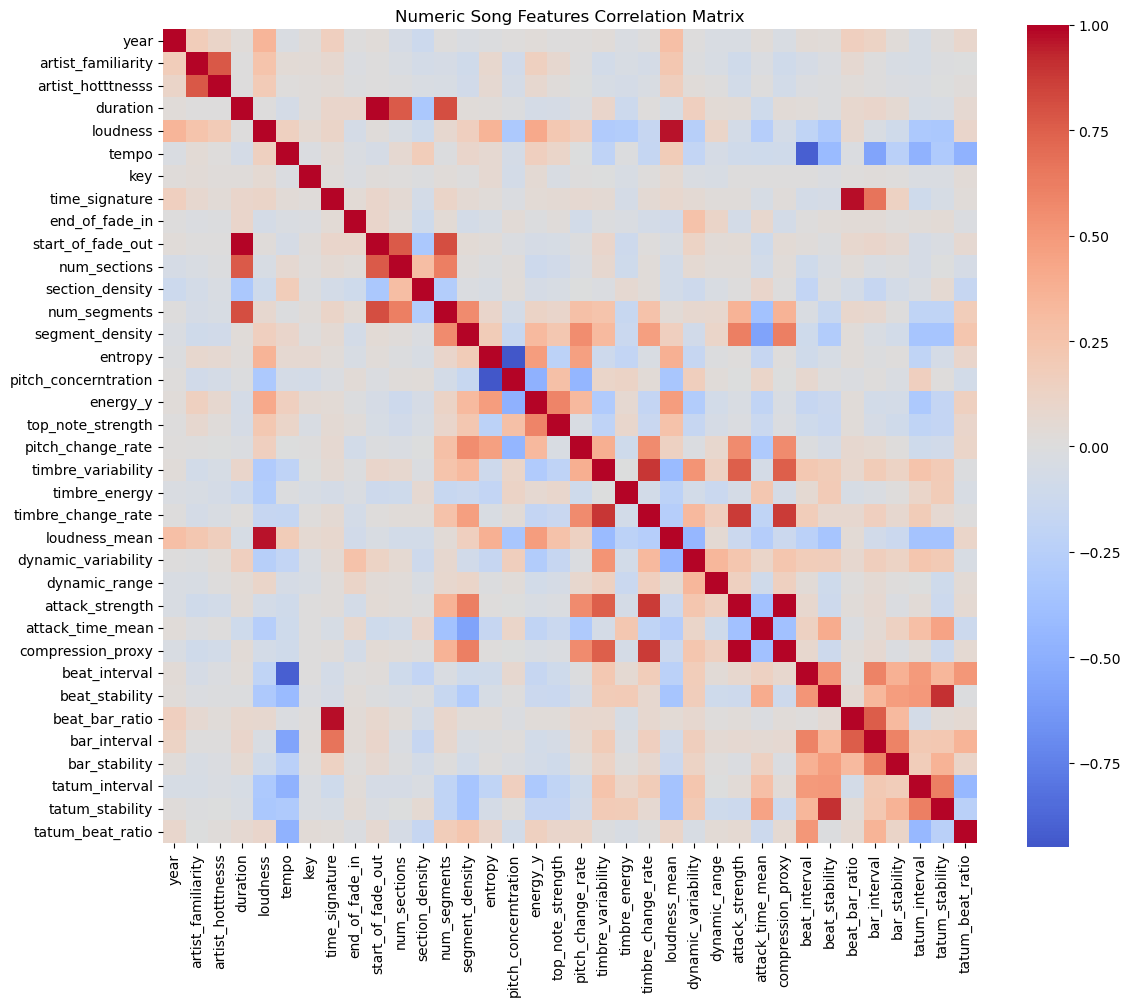

In [124]:
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Numeric Song Features Correlation Matrix')
plt.tight_layout()
plt.show()

In [125]:
# find high corr (> 0.80 pair
threshold = 0.85

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0':'feature_1',
             'level_1':'feature_2',
             0:'correlation'
         })
)

high_corr = high_corr[
    high_corr['correlation'].abs() > threshold
].sort_values(
    'correlation',
    ascending=False
)

print(high_corr)

              feature_1             feature_2  correlation
576     attack_strength     compression_proxy     1.000000
107            duration     start_of_fade_out     0.997643
246      time_signature        beat_bar_ratio     0.976690
151            loudness         loudness_mean     0.966702
613      beat_stability       tatum_stability     0.908062
495  timbre_variability    timbre_change_rate     0.886742
528  timbre_change_rate       attack_strength     0.876151
530  timbre_change_rate     compression_proxy     0.876151
187               tempo         beat_interval    -0.911744
399             entropy  pitch_concerntration    -0.950939



DROP:
- loudness_mean
- tatum_stability 
- timbre_change_rate  
- beat_interval  
- entropy


In [126]:
drop_cols = ['attack_strength', 'loudness_mean', 'start_of_fade_out', 'beat_bar_ratio', 'tatum_stability', 'timbre_change_rate', 'beat_interval', 'entropy', 'year']
metadata_audio_filtered = metadata_audio_working.drop(columns=drop_cols).reset_index(drop=True)

<Figure size 1200x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Numeric Song Features Correlation Matrix (filtered)')

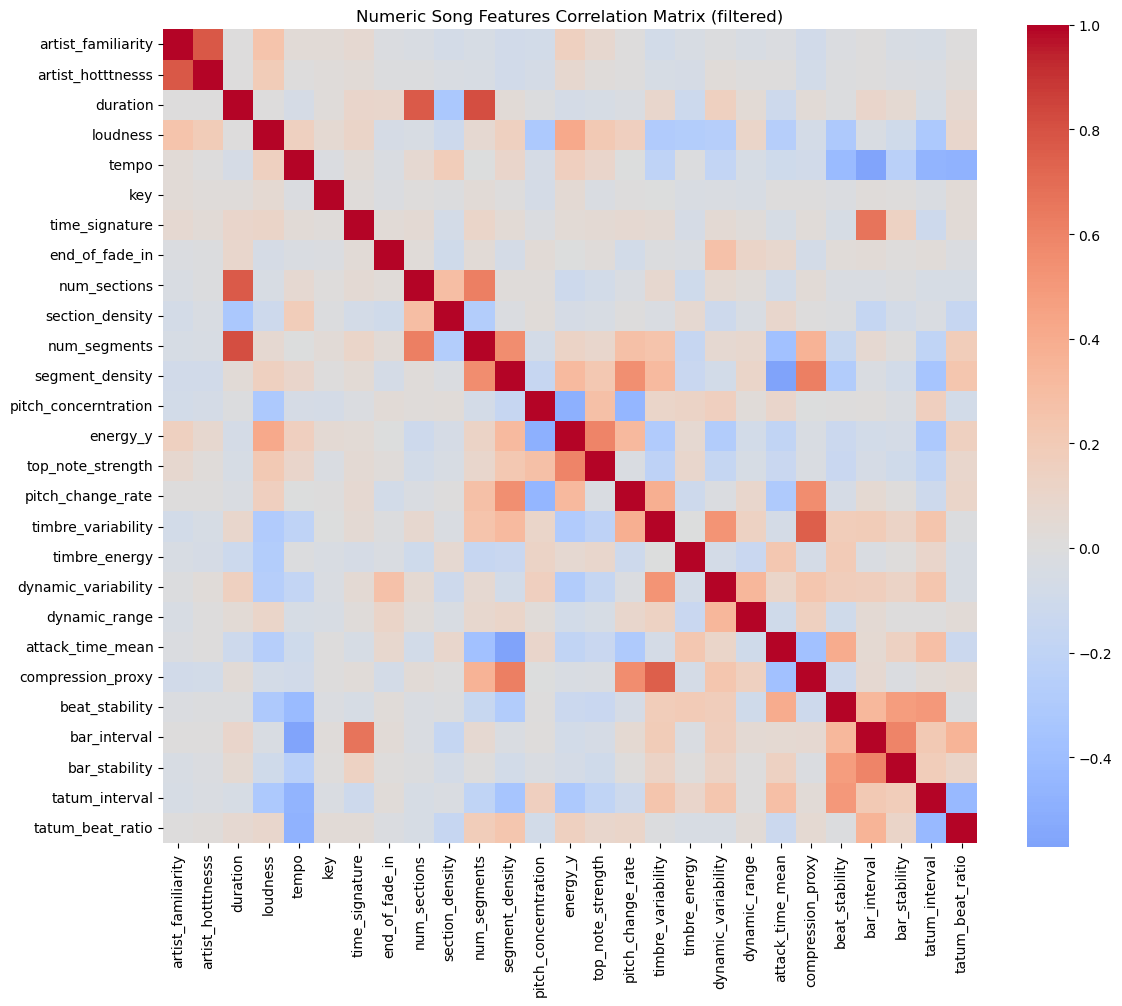

In [127]:
numeric_cols_2 = metadata_audio_filtered.select_dtypes(include=np.number).columns
corr2 = metadata_audio_filtered [numeric_cols_2].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr2,
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Numeric Song Features Correlation Matrix (filtered)')
plt.tight_layout()
plt.show()

In [128]:
metadata_audio_filtered.set_index('song_id', drop=True, inplace=True)

In [129]:
metadata_audio_filtered.head()

,artist_name,song_title,release,artist_familiarity,artist_hotttnesss,artist_terms,duration,loudness,tempo,key,...,dynamic_variability,dynamic_range,attack_time_mean,compression_proxy,beat_stability,bar_interval,bar_stability,tatum_interval,tatum_beat_ratio,era
song_id,,,,,,,,,,,,,,,,,,,,,
SOZQSGL12AF72A9145,Dead Kennedys,Halloween,Milking The Sacred Cow,0.737038,0.539245,"rock, hardcore punk, alternative punk rock, pu...",216.84200,-4.264,92.897,10,...,3.497104,27.327,0.059464,5.309333,0.009639,2.582028,0.035344,0.161342,4.000000,80s
SOKMPKV12A67AE241B,Shadows Fall,What Drives The Weak,The War Within,0.733433,0.455559,"power metal, hardcore punk, heavy metal, death...",283.48036,-4.076,84.992,0,...,3.230603,58.266,0.047723,5.876123,0.002254,2.823591,0.004910,0.176463,4.000000,00s
SOBHQIJ12A6D4FC7D3,Spoonie Gee,Spoonie Is Back,The Sugar Hill Records Story,0.618692,0.422721,"hip hop, pop rap, disco, old school hip hop, e...",393.63873,-6.619,135.503,1,...,6.089560,58.218,0.042906,12.835682,0.002362,2.214326,0.007489,0.147617,2.998871,Unknown
SOZKFHV12A6D4F996F,Phil Collins,I'm Not Moving,Face Value,0.655921,0.578302,"soft rock, pop rock, ballad, easy listening, c...",154.93179,-15.433,100.042,5,...,9.589783,50.534,0.051313,9.793949,0.018781,2.423296,0.180778,0.299225,2.000000,80s
SOIAZJL12A6D4F854E,Kiss,Radar For Love,Asylum,0.773076,0.586730,"hard rock, heavy metal, rock, new york, guitar...",241.08363,-8.021,99.761,9,...,8.560017,56.025,0.071525,4.772836,0.034983,0.601021,0.034983,0.300466,2.000000,Unknown


## Song Feature Similarity Matrix Construction

In [130]:
metadata_audio_filtered.shape

(1624, 33)

In [131]:
metadata_audio_filtered.dtypes

artist_name               object
song_title                object
release                   object
artist_familiarity       float64
artist_hotttnesss        float64
artist_terms              object
duration                 float64
loudness                 float64
tempo                    float64
key                        int64
time_signature             int64
end_of_fade_in           float64
track_tags                object
num_sections               int64
section_density          float64
num_segments               int64
segment_density          float64
pitch_concerntration     float64
energy_y                 float64
top_note_strength        float64
pitch_change_rate        float64
timbre_variability       float64
timbre_energy            float64
dynamic_variability      float64
dynamic_range            float64
attack_time_mean         float64
compression_proxy        float64
beat_stability           float64
bar_interval             float64
bar_stability            float64
tatum_inte

In [132]:
song_ids = metadata_audio_filtered.index.tolist()

# MAPPING
song_id_to_idx = {song_id: idx for idx, song_id in enumerate(song_ids)}
idx_to_song_id = {idx: song_id for idx, song_id in enumerate(song_ids)}

In [133]:
# types of features
text_cols = ['artist_name', 'artist_terms', 'track_tags']
numeric_cols = ['artist_familiarity', 'artist_hotttnesss', 'duration', 'loudness', 'tempo',
               'end_of_fade_in', 'num_sections', 'section_density', 'num_segments', 'segment_density',
               'pitch_concerntration', 'energy_y', 'top_note_strength', 'pitch_change_rate', 'timbre_variability',
               'timbre_energy', 'dynamic_variability', 'dynamic_range', 'attack_time_mean', 'compression_proxy',
               'beat_stability', 'bar_interval', 'bar_stability', 'tatum_interval', 'tatum_beat_ratio']
categorical_cols = ['era', 'key', 'time_signature']

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# scaling numeric features
scaler = StandardScaler()
X_num = scaler.fit_transform(metadata_audio_filtered[numeric_cols])

# one-hot encoded cat features
ohe = OneHotEncoder(
    sparse_output=True,
    handle_unknown='ignore'
)
X_cat = ohe.fit_transform(metadata_audio_filtered[categorical_cols])

In [135]:
metadata_audio_filtered['track_tags'] = metadata_audio_filtered['track_tags'].fillna('')
metadata_audio_filtered.head()

,artist_name,song_title,release,artist_familiarity,artist_hotttnesss,artist_terms,duration,loudness,tempo,key,...,dynamic_variability,dynamic_range,attack_time_mean,compression_proxy,beat_stability,bar_interval,bar_stability,tatum_interval,tatum_beat_ratio,era
song_id,,,,,,,,,,,,,,,,,,,,,
SOZQSGL12AF72A9145,Dead Kennedys,Halloween,Milking The Sacred Cow,0.737038,0.539245,"rock, hardcore punk, alternative punk rock, pu...",216.84200,-4.264,92.897,10,...,3.497104,27.327,0.059464,5.309333,0.009639,2.582028,0.035344,0.161342,4.000000,80s
SOKMPKV12A67AE241B,Shadows Fall,What Drives The Weak,The War Within,0.733433,0.455559,"power metal, hardcore punk, heavy metal, death...",283.48036,-4.076,84.992,0,...,3.230603,58.266,0.047723,5.876123,0.002254,2.823591,0.004910,0.176463,4.000000,00s
SOBHQIJ12A6D4FC7D3,Spoonie Gee,Spoonie Is Back,The Sugar Hill Records Story,0.618692,0.422721,"hip hop, pop rap, disco, old school hip hop, e...",393.63873,-6.619,135.503,1,...,6.089560,58.218,0.042906,12.835682,0.002362,2.214326,0.007489,0.147617,2.998871,Unknown
SOZKFHV12A6D4F996F,Phil Collins,I'm Not Moving,Face Value,0.655921,0.578302,"soft rock, pop rock, ballad, easy listening, c...",154.93179,-15.433,100.042,5,...,9.589783,50.534,0.051313,9.793949,0.018781,2.423296,0.180778,0.299225,2.000000,80s
SOIAZJL12A6D4F854E,Kiss,Radar For Love,Asylum,0.773076,0.586730,"hard rock, heavy metal, rock, new york, guitar...",241.08363,-8.021,99.761,9,...,8.560017,56.025,0.071525,4.772836,0.034983,0.601021,0.034983,0.300466,2.000000,Unknown


In [136]:
# text columns
from sklearn.feature_extraction.text import TfidfVectorizer

def comma_tokenizer(x):
    if pd.isna(x):
        return []
    return [tag.strip().lower() for tag in str(x).split(',') if tag.strip()]

artist_tfidf = TfidfVectorizer(
    tokenizer=comma_tokenizer,
    token_pattern=None,
    lowercase=False,   # already lowercased in tokenizer
    binary=True,       # tag exists or not
    min_df=5,          # remove very rare tags
    max_df=0.8,        # remove too common tags
    max_features=500   # optional; adjust later
)

track_tfidf = TfidfVectorizer(
    tokenizer=comma_tokenizer,
    token_pattern=None,
    lowercase=False,   # already lowercased in tokenizer
    binary=True,       # tag exists or not
    min_df=5,          # remove very rare tags
    max_df=0.8,        # remove too common tags
    max_features=500   # optional; adjust later
)

X_artist_terms = artist_tfidf.fit_transform(metadata_audio_filtered['artist_terms'])
X_track_tags = track_tfidf.fit_transform(metadata_audio_filtered['track_tags'])

In [137]:
from scipy.sparse import hstack

song_content = hstack([X_num, X_cat, X_artist_terms, X_track_tags])

In [138]:
print(song_content.shape)

(1624, 1049)


#### Analyze contribution

In [139]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

S_num = cosine_similarity(X_num)
S_cat = cosine_similarity(X_cat)
S_artist = cosine_similarity(X_artist_terms)
S_tags = cosine_similarity(X_track_tags)
S_all = cosine_similarity(song_content)

In [140]:
def upper_tri_values(S):
    idx = np.triu_indices_from(S, k=1)
    return S[idx]

blocks = {
    "audio_numeric": S_num,
    "categorical": S_cat,
    "artist_terms": S_artist,
    "track_tags": S_tags
}

for name, S_block in blocks.items():
    corr = np.corrcoef(
        upper_tri_values(S_all),
        upper_tri_values(S_block)
    )[0, 1]
    print(name, corr)

audio_numeric 0.9849954646763255
categorical 0.18621819915065646
artist_terms 0.18919632986209423
track_tags 0.15568933869836352


#### Feature Normalization
- normalize for each type and combine

In [141]:
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

X_num_n = normalize(csr_matrix(X_num))
X_cat_n = normalize(X_cat)
X_artist_n = normalize(X_artist_terms)
X_tags_n = normalize(X_track_tags)

In [142]:
# can choose to stack with weights
X_content = hstack([
    1.0 * X_num_n,
    0.3 * X_cat_n,
    0.7 * X_artist_n,
    0.7 * X_tags_n
])

X_content = normalize(X_content)

In [143]:
from scipy.sparse.linalg import norm
norm(X_content[0])

np.float64(0.9999999999999999)

In [144]:
S_content = cosine_similarity(X_content)

## DPP with Song Feature Similarity Matrix

In [145]:
#0 - User-Song Matrix
R_train_1, test_df_1 =  hide_m_song_per_user(R)
row_norms = np.linalg.norm(R_train_1, axis=1, keepdims=True)
R_train_normalized = R_train_1 / row_norms

# compute cosine similarity on normalized R (similarty on collaborative data)
S = cosine_similarity(R_train_normalized.T)
# remove self-similarity
np.fill_diagonal(S, 0)
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [146]:
#1. SELECT SPECIFIC USERS AND SET U OF THEIR LISTENED SONGS
active_user_id = R_train_normalized.index[5]

#2. CANDIDATE SET C - from item-based collaborative filtering
candidate_df = item_based_candidate_set(active_user_id, R_train_normalized, S, k=50)
candidate_df['score_rank'] = candidate_df.index + 1
candidate_df

,song_id,score,score_rank
0,SOKUUOE12A6D4F80EB,0.097314,1
1,SOREJVE12A58A7AD36,0.094700,2
2,SOJBRYI12A6D4F80EF,0.070968,3
3,SOIDHVM12AB0183B34,0.041420,4
4,SOXUAQZ12AB0184442,0.040033,5
...,...,...,...
191,SOJPNCH12A67AE0E21,0.011908,192
192,SOGOBGK12AF72A633B,0.011531,193
193,SOKJITL12AB017E7FF,0.011235,194
194,SOBGXEU12A8AE45903,0.011064,195


In [147]:
# 3. SONG CONTENT SIMILARITY MATRIX
S_content = pd.DataFrame(S_content,
                         index=song_ids,
                         columns=song_ids)
S_content

,SOZQSGL12AF72A9145,SOKMPKV12A67AE241B,SOBHQIJ12A6D4FC7D3,SOZKFHV12A6D4F996F,SOIAZJL12A6D4F854E,SOMAFQT12A8AE47E8D,SOIKPOX12A58A7BA0B,SOMZNFA12A6D4F8A2A,SOSQIHH12A8C13370B,SOGHPNO12A582A2482,...,SOGWPDK12A81C2242F,SOGRTXS12AB017CCFC,SOPWWAV12A8C13A825,SOIBHJO12A6D4F7774,SOQZZKI12A67020D38,SOVQEYV12AF72A06B2,SOTSKKZ12A6D4F71C4,SOYJHEW12A8C133A40,SOOFHUH12A8C1340A5,SOVVGSH12A8C14085F
SOZQSGL12AF72A9145,1.000000,0.418190,0.046759,-0.124273,0.091033,0.227031,0.185047,-0.110192,0.147417,-0.181788,...,0.087906,-0.081323,0.246501,-0.015781,-0.099336,0.109883,-0.240162,0.049485,0.264178,-0.127438
SOKMPKV12A67AE241B,0.418190,1.000000,0.151530,-0.189517,0.021008,0.338648,0.312802,-0.033580,0.055292,-0.167653,...,0.222271,0.048161,0.021904,0.112540,0.029479,0.152366,-0.220161,0.180244,-0.004290,-0.050324
SOBHQIJ12A6D4FC7D3,0.046759,0.151530,1.000000,-0.058481,0.030309,0.224490,0.296407,0.115133,0.189688,-0.111964,...,0.404908,0.259907,-0.153741,0.318215,0.022108,-0.042806,-0.058798,0.380650,-0.169843,0.210721
SOZKFHV12A6D4F996F,-0.124273,-0.189517,-0.058481,1.000000,0.054924,-0.069894,0.046499,0.019620,0.046116,0.042086,...,-0.006990,0.011794,-0.093150,0.120096,0.095195,-0.225321,0.214322,0.021352,-0.019353,0.060261
SOIAZJL12A6D4F854E,0.091033,0.021008,0.030309,0.054924,1.000000,-0.190774,-0.124936,-0.169882,-0.086571,-0.112538,...,-0.129969,-0.181846,0.188552,-0.009626,0.036258,0.090680,-0.080162,0.054341,0.096945,-0.220662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SOVQEYV12AF72A06B2,0.109883,0.152366,-0.042806,-0.225321,0.090680,-0.045551,-0.090019,0.033025,0.111775,0.090886,...,-0.053064,0.075044,0.272210,-0.190641,0.056771,1.000000,-0.073563,-0.064250,0.368228,0.073744
SOTSKKZ12A6D4F71C4,-0.240162,-0.220161,-0.058798,0.214322,-0.080162,0.035055,-0.164019,0.368468,-0.219130,0.211768,...,0.004998,0.168143,-0.004420,0.131785,0.339701,-0.073563,1.000000,-0.085249,-0.062718,0.223073
SOYJHEW12A8C133A40,0.049485,0.180244,0.380650,0.021352,0.054341,0.215890,0.265948,0.101362,0.078317,-0.238499,...,0.374383,0.263729,-0.086794,0.440739,0.047918,-0.064250,-0.085249,1.000000,-0.200260,0.182633
SOOFHUH12A8C1340A5,0.264178,-0.004290,-0.169843,-0.019353,0.096945,0.004103,-0.154959,0.062438,0.210186,0.174404,...,-0.036392,0.183356,0.392094,-0.183846,-0.107062,0.368228,-0.062718,-0.200260,1.000000,0.060747


In [148]:
#4. DPP RERANK ON CANDIDATE SET with SONG CONTENT SIMILARITY
dpp_df_content = dpp_rerank(candidate_df=candidate_df, S=S_content, N=20)
dpp_df_content_song = dpp_df_content['song_id'].tolist()
dpp_df_content

,song_id,score,score_rank,dpp_rank
82,SOKXYUW12A8C140229,0.104816,83,1
0,SOKUUOE12A6D4F80EB,0.097314,1,2
1,SOREJVE12A58A7AD36,0.094700,2,3
84,SOFKEDR12A8C13D381,0.096285,85,4
86,SOEHTZE12A6310F0F2,0.078208,87,5
41,SOSELMV12A6D4FCF5A,0.084993,42,6
85,SOPWKOX12A8C139D43,0.077097,86,7
2,SOJBRYI12A6D4F80EF,0.070968,3,8
87,SOKZTHA12A8C134830,0.076683,88,9
91,SOOSBQP12A8C1353B6,0.066569,92,10


In [149]:
# Equal Weighted
alpha = 0.5
S_hybrid = alpha * S + (1 - alpha) * S_content

dpp_df_hybrid = dpp_rerank(candidate_df=candidate_df, S=S_hybrid, N=20)
dpp_df_hybrid_song = dpp_df_hybrid['song_id'].tolist()

In [150]:
len(set(dpp_df_hybrid_song).intersection(set(dpp_df_song)))

19

## Evaluation Content-DPP & Hybrid-DPP - masked 1 song per user for test set

In [201]:
# train-test set
R_train_2, test_df_2 = hide_m_song_per_user(R, m=1)
row_norms = np.linalg.norm(R_train_2, axis=1, keepdims=True)
R_train_normalized = R_train_2 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [202]:
common_ids = S.index.intersection(S_content.index)
len(common_ids)

1624

In [203]:
S_aligned = S.loc[common_ids, common_ids]
S_content_aligned = S_content.loc[common_ids, common_ids]

alpha = 0.5

S_hybrid = alpha * S_aligned + (1 - alpha) * S_content_aligned

In [ ]:
# recommend for all unique user in train-test set
unique_users_2 = test_df_2['user_id'].unique().tolist()
hit_rate_2 = []
mrr_metrics_2 = []
ilad_metrics_2 = []
ilmd_metrics_2 = []
ilad_f = []
ilmd_f = []

for user_id in unique_users_2:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    
    dpp_set = dpp_rerank(candidate_u, S_content, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate_2.append(hitrate_at_N(recommended, relevant))
    mrr_metrics_2.append(mrr_at_N(recommended, relevant))
    ilad_metrics_2.append(ilad(recommended, S))
    ilmd_metrics_2.append(ilmd(recommended, S))
    ilad_f.append(ilad(recommended, S_content))
    ilmd_f.append(ilmd(recommended, S_content))

recall_2 = np.mean(hit_rate_2)
mrr_dpp_2 = np.mean(mrr_metrics_2)
ilad_dpp_2 = np.mean(ilad_metrics_2)
ilmd_dpp_2 = np.mean(ilmd_metrics_2)
ilad_dpp_f = np.mean(ilad_f)
ilmd_dpp_f = np.mean(ilmd_f)

In [ ]:
recall_2
mrr_dpp_2 
(ilad_dpp + ilad_dpp_f)/2
(ilmd_dpp_f + ilmd_dpp)/2

In [156]:
# recommend for all unique user in train-test set (hybrid)
unique_users_2 = test_df_2['user_id'].unique().tolist()
hit_rate_2 = []
mrr_metrics_2 = []
ilad_metrics_2 = []
ilmd_metrics_2 = []

for user_id in unique_users_2:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    
    dpp_set = dpp_rerank(candidate_u, S_hybrid, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate_2.append(hitrate_at_N(recommended, relevant))
    mrr_metrics_2.append(mrr_at_N(recommended, relevant))
    ilad_metrics_2.append(ilad(recommended, S))
    ilmd_metrics_2.append(ilmd(recommended, S))

recall_2 = np.mean(hit_rate_2)
mrr_dpp_2 = np.mean(mrr_metrics_2)
ilad_dpp_2 = np.mean(ilad_metrics_2)
ilmd_dpp_2 = np.mean(ilmd_metrics_2)

In [157]:
recall_2 
mrr_dpp_2 
ilad_dpp_2 
ilmd_dpp_2 

np.float64(0.5101144626016846)

np.float64(0.23586468498688093)

np.float64(0.9576833655235985)

np.float64(0.6037018906132697)

## Evaluation Content-DPP & Hybrid-DPP - masked 3 song per user for test set

In [158]:
# train-test set
R_train_2, test_df_2 = hide_m_song_per_user(R, m=3)
row_norms = np.linalg.norm(R_train_2, axis=1, keepdims=True)
R_train_normalized = R_train_2 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [159]:
common_ids = S.index.intersection(S_content.index)

S_aligned = S.loc[common_ids, common_ids]
S_content_aligned = S_content.loc[common_ids, common_ids]

alpha = 0.5

S_hybrid = alpha * S_aligned + (1 - alpha) * S_content_aligned

In [160]:
# recommend for all unique user in train-test set
unique_users_2 = test_df_2['user_id'].unique().tolist()
hit_rate_2 = []
mrr_metrics_2 = []
ilad_metrics_2 = []
ilmd_metrics_2 = []
iladf  = []
ilmdf = []

for user_id in unique_users_2:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    
    dpp_set = dpp_rerank(candidate_u, S_content, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate_2.append(hitrate_at_N(recommended, relevant))
    mrr_metrics_2.append(mrr_at_N(recommended, relevant))
    ilad_metrics_2.append(ilad(recommended, S))
    ilmd_metrics_2.append(ilmd(recommended, S))

recall_2 = np.mean(hit_rate_2)
mrr_dpp_2 = np.mean(mrr_metrics_2)
ilad_dpp_2 = np.mean(ilad_metrics_2)
ilmd_dpp_2 = np.mean(ilmd_metrics_2)

In [161]:
recall_2 
mrr_dpp_2 
ilad_dpp_2 
ilmd_dpp_2 

np.float64(0.6499172125836873)

np.float64(0.3332453843911276)

np.float64(0.9805445317870828)

np.float64(0.7410146878177651)

In [162]:
# recommend for all unique user in train-test set - hybrid
unique_users_2 = test_df_2['user_id'].unique().tolist()
hit_rate_2 = []
mrr_metrics_2 = []
ilad_metrics_2 = []
ilmd_metrics_2 = []

for user_id in unique_users_2:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    
    dpp_set = dpp_rerank(candidate_u, S_hybrid, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate_2.append(hitrate_at_N(recommended, relevant))
    mrr_metrics_2.append(mrr_at_N(recommended, relevant))
    ilad_metrics_2.append(ilad(recommended, S))
    ilmd_metrics_2.append(ilmd(recommended, S))

recall_2 = np.mean(hit_rate_2)
mrr_dpp_2 = np.mean(mrr_metrics_2)
ilad_dpp_2 = np.mean(ilad_metrics_2)
ilmd_dpp_2 = np.mean(ilmd_metrics_2)

In [163]:
recall_2 
mrr_dpp_2 
ilad_dpp_2 
ilmd_dpp_2 

np.float64(0.6555323590814196)

np.float64(0.33552328109735535)

np.float64(0.9791274890145779)

np.float64(0.7535609956480275)

# Evaluation
- A hit = if the relevant items appear in the recommend items for each user 
- Recall (of a system) = # of hits / number of total users = n#

In [94]:
# hit rate
def hitrate_at_N(recommended, relevant):
    return int(len(set(recommended) & set(relevant)) > 0)

In [95]:
# MRR 
def mrr_at_N(recommended, relevant):
    relevant_items = set(relevant)

    for rank, item in enumerate(recommended, start=1):
        if item in relevant_items:
            return 1 / rank

    return 0

In [96]:
# ILAD = Average pairwise distance among recommended items (the higher the more diverse)
def ilad(recommended_items, S):
    distances = []

    for i in range(len(recommended_items)):
        for j in range(i + 1, len(recommended_items)):

            item_i = recommended_items[i]
            item_j = recommended_items[j]

            similarity = S.loc[item_i, item_j]

            distance = 1 - similarity

            distances.append(distance)

    if len(distances) == 0:
        return 0

    return np.mean(distances)

In [97]:
# ILMD =  measure distance of the MOST similar pair in recommendation list (high means even closest pair still diverse)
def ilmd(recommended_items, S):
    distances = []

    for i in range(len(recommended_items)):
        for j in range(i + 1, len(recommended_items)):

            item_i = recommended_items[i]
            item_j = recommended_items[j]

            similarity = S.loc[item_i, item_j]

            distance = 1 - similarity

            distances.append(distance)

    if len(distances) == 0:
        return 0

    return np.min(distances)

### Baseline Evaluation 1 with Hit Rate - Recall
- masked only one song per user for test set

In [198]:
# train-test set
R_train_1, test_df_1 = hide_m_song_per_user(R)
row_norms = np.linalg.norm(R_train_1, axis=1, keepdims=True)
R_train_normalized = R_train_1 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [199]:
# recommend for all unique user in train-test set
unique_users = test_df_1['user_id'].unique().tolist()
hit_rate = []
mrr_metrics = []
ilad_metrics = []
ilmd_metrics = []
ilad_f = []
ilmd_f = []

for user_id in unique_users:
    candidate_df = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    recommendation_df = item_based_CF_recommend(candidate_df, N=20)
    recommended = recommendation_df['song_id'].tolist()
    relevant = test_df_1[test_df_1['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate.append(hitrate_at_N(recommended, relevant))
    mrr_metrics.append(mrr_at_N(recommended, relevant))
    ilad_metrics.append(ilad(recommended, S))
    ilmd_metrics.append(ilmd(recommended, S))
    ilad_f.append(ilad(recommended, S_content))
    ilmd_f.append(ilmd(recommended, S_content))

In [200]:
recall = np.mean(hit_rate)
mrr_dpp = np.mean(mrr_metrics)
ilad_dpp = np.mean(ilad_metrics)
ilmd_dpp = np.mean(ilmd_metrics)
ilad_dpp_f = np.mean(ilad_f)
ilmd_dpp_f = np.mean(ilmd_f)

recall
mrr_dpp
(ilad_dpp + ilad_dpp_f)/2
(ilmd_dpp_f + ilmd_dpp)/2

np.float64(0.5106903750629904)

np.float64(0.2358202579417014)

np.float64(0.9010650423764526)

np.float64(0.4409765469687872)

### Baseline Evaluation 2 with Hit Rate - Recall
- masked 3 songs per user for test set

In [101]:
# train-test set
R_train_2, test_df_2 = hide_m_song_per_user(R, m=3)
row_norms = np.linalg.norm(R_train_2, axis=1, keepdims=True)
R_train_normalized = R_train_2 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [102]:
# recommend for all unique user in train-test set
unique_users_2 = test_df_1['user_id'].unique().tolist()
hit_rate_2 = 0
n_2 = len(unique_users)

for user_id in unique_users_2:
    candidate_df = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    recommendation_df = item_based_CF_recommend(candidate_df, N=20)
    recommended = recommendation_df['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    hit_rate_2 += hitrate_at_N(recommended, relevant)

recall_2 = hit_rate_2 / n_2

In [103]:
recall_2

0.6581239651572961

### DPP Rerank Evaluation 1 
- masked 1 song per user for test set

In [194]:
# train-test set
R_train_1, test_df_1 = hide_m_song_per_user(R)
row_norms = np.linalg.norm(R_train_1, axis=1, keepdims=True)
R_train_normalized = R_train_1 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [195]:
# recommend for all unique user in train-test set
unique_users = test_df_1['user_id'].unique().tolist()
hit_rate = []
mrr_metrics = []
ilad_metrics = []
ilmd_metrics = []
ilad_f = []
ilmd_f = []

for user_id in unique_users:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    dpp_set = dpp_rerank(candidate_u, S, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_1[test_df_1['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate.append(hitrate_at_N(recommended, relevant))
    mrr_metrics.append(mrr_at_N(recommended, relevant))
    ilad_metrics.append(ilad(recommended, S))
    ilmd_metrics.append(ilmd(recommended, S))
    ilad_f.append(ilad(recommended, S_content))
    ilmd_f.append(ilmd(recommended, S_content))

recall = np.mean(hit_rate)
mrr_dpp = np.mean(mrr_metrics)
ilad_dpp = np.mean(ilad_metrics)
ilmd_dpp = np.mean(ilmd_metrics)
ilad_dpp_f = np.mean(ilad_f)
ilmd_dpp_f = np.mean(ilmd_f)

In [196]:
recall
mrr_dpp
ilad_dpp
ilmd_dpp
ilad_dpp_f
ilmd_dpp_f

np.float64(0.511770210927939)

np.float64(0.23631023747859983)

np.float64(0.9569552326664958)

np.float64(0.6099770474834608)

np.float64(0.8489515021919408)

np.float64(0.31252154473742944)

In [197]:
(ilad_dpp + ilad_dpp_f)/2
(ilmd_dpp_f + ilmd_dpp)/2

np.float64(0.9029533674292183)

np.float64(0.46124929611044513)

### DPP Rerank Evaluation 2
- masked 3 song per user for test set

In [111]:
# train-test set
R_train_2, test_df_2 = hide_m_song_per_user(R, m=3)
row_norms = np.linalg.norm(R_train_2, axis=1, keepdims=True)
R_train_normalized = R_train_2 / row_norms                     # user-song matix row normalization 

# item similarity 
S = cosine_similarity(R_train_normalized.T)                    # compute cosine similarity on normalized R
np.fill_diagonal(S, 0)                                         # remove self-similarity
S = pd.DataFrame(S, index=R_train_normalized.columns, columns=R_train_normalized.columns)

In [112]:
# recommend for all unique user in train-test set
unique_users_2 = test_df_2['user_id'].unique().tolist()
hit_rate_2 = []
mrr_metrics_2 = []
ilad_metrics_2 = []
ilmd_metrics_2 = []

for user_id in unique_users_2:
    
    candidate_u = item_based_candidate_set(user_id, R_train_normalized, S, k=50)
    dpp_set = dpp_rerank(candidate_u, S, N=20, eps=1e-8)
    
    recommended = dpp_set['song_id'].tolist()
    relevant = test_df_2[test_df_2['user_id'] == user_id]['hidden_song_id'].tolist()

    # evaluate
    hit_rate_2.append(hitrate_at_N(recommended, relevant))
    mrr_metrics_2.append(mrr_at_N(recommended, relevant))
    ilad_metrics_2.append(ilad(recommended, S))
    ilmd_metrics_2.append(ilmd(recommended, S))

recall_2 = np.mean(hit_rate_2)
mrr_dpp_2 = np.mean(mrr_metrics_2)
ilad_dpp_2 = np.mean(ilad_metrics_2)
ilmd_dpp_2 = np.mean(ilmd_metrics_2)

In [113]:
recall
mrr_dpp_2
ilad_dpp_2
ilmd_dpp_2

np.float64(0.511770210927939)

np.float64(0.3362143003310425)

np.float64(0.9788233080447235)

np.float64(0.7760472871284556)